# Лекция 1. Алгоритмы и язык Python

## Красота языка программирования Python
*Язык Python — универсальный, кроcсплатформенный, красивый.*

``` pycon
>>> import antigravity
```
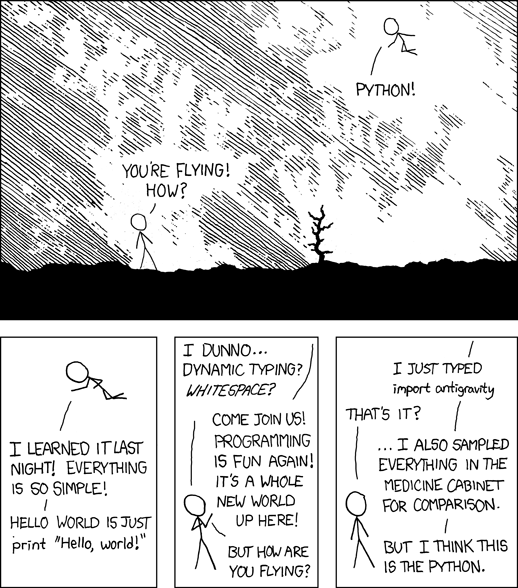


Его можно применять для любых целей почти на любых платформах, и делать это легко и удобно.


### Области использования языка Python

Язык Python очень **популярен в веб-разработке**.
Во многих прикладных программах, таких как офисные приложения или графические редакторы, Python выбирают как основной **язык для скриптов**, позволяющих автоматизировать рутинные действия.
Системные администраторы Linux всё чаще используют его **для управления операционной системой**.
Наконец, когда требуется **анализировать данные**, речь всегда заходит о выборе языка Python.

### Популярность в мире

Python был использован при создании таких сервисов, как YouTube, DropBox, Google, Instagram, Spotify, а также замечательной программы BitTorrent.

Трудно найти современный крупный проект, в котором Python не использовался бы вообще, хотя чаще всего он не является единственным языком проекта.

Давайте посмотрим, как изменяется популярность языков программирования в мире, с помощью Python. (*Внимание! Код, представленный ниже, на данном этапе предназначен для ознакомления, пока вы не обязаны уметь в нем разбираться*.)

Ниже представлены топ-20 языков программирования по [индексу TIOBE](https://ru.wikipedia.org/wiki/Индекс_TIOBE) (индекс рассчитывается на основе результатов поисковых запросов).

In [ ]:
!pip install -q tiobeindexpy

In [ ]:
!pip install lxml

In [ ]:
from tiobeindexpy import tiobeindexpy as tbpy # for programming languages ranking
top_20 = tbpy.top_20()
top_20.drop(["Change", "Programming Language"], axis=1, inplace=True)
top_20

/usr/local/lib/python3.10/dist-packages/tiobeindexpy/tiobeindexpy.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(tables[0]), header = 0)[0]


,Sep 2024,Sep 2023,Programming Language.1,Ratings,Change.1
0,1,1,Python,20.17%,+6.01%
1,2,3,C++,10.75%,+0.09%
2,3,4,Java,9.45%,-0.04%
3,4,2,C,8.89%,-2.38%
4,5,5,C#,6.08%,-1.22%
5,6,6,JavaScript,3.92%,+0.62%
6,7,7,Visual Basic,2.70%,+0.48%
7,8,12,Go,2.35%,+1.16%
8,9,10,SQL,1.94%,+0.50%
9,10,11,Fortran,1.78%,+0.49%


Теперь визуализируем популярность языков горизонтальной гистограммой:

/usr/local/lib/python3.10/dist-packages/tiobeindexpy/tiobeindexpy.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(tables[0]), header = 0)[0]


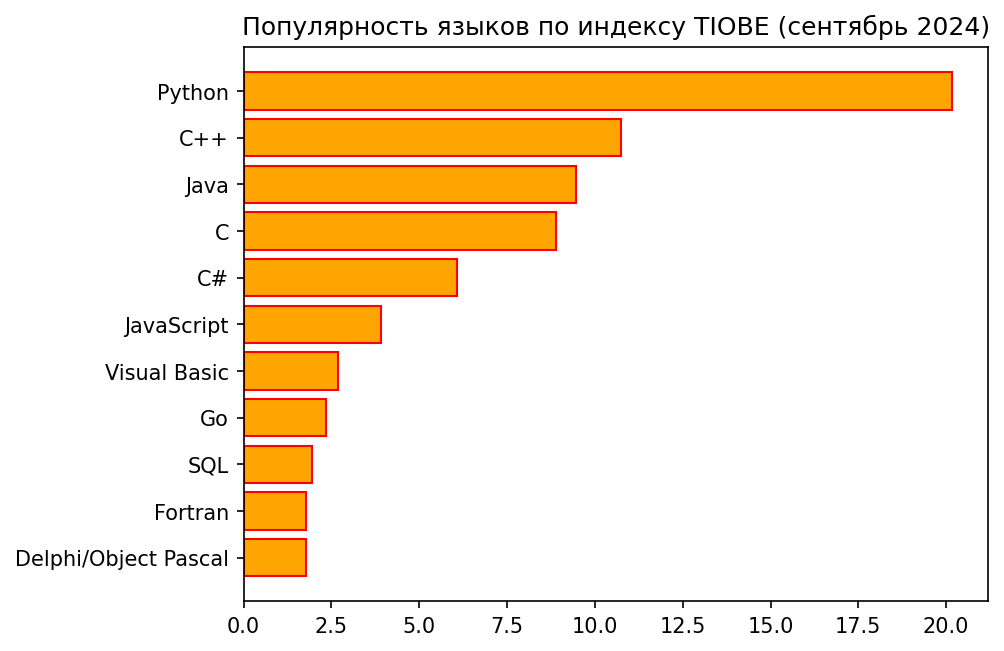

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

top_20 = tbpy.top_20()
fig, ax = plt.subplots(1, 1)
fig.dpi = 150
plt.barh(top_20['Programming Language.1'][10::-1],
         top_20['Ratings'].apply(lambda x: float(x.strip("%")))[10::-1],
         color='orange', edgecolor='red')
plt.title('Популярность языков по индексу TIOBE (сентябрь 2024)')
plt.show()

/usr/local/lib/python3.10/dist-packages/tiobeindexpy/tiobeindexpy.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(tables[0]), header = 0)[0]


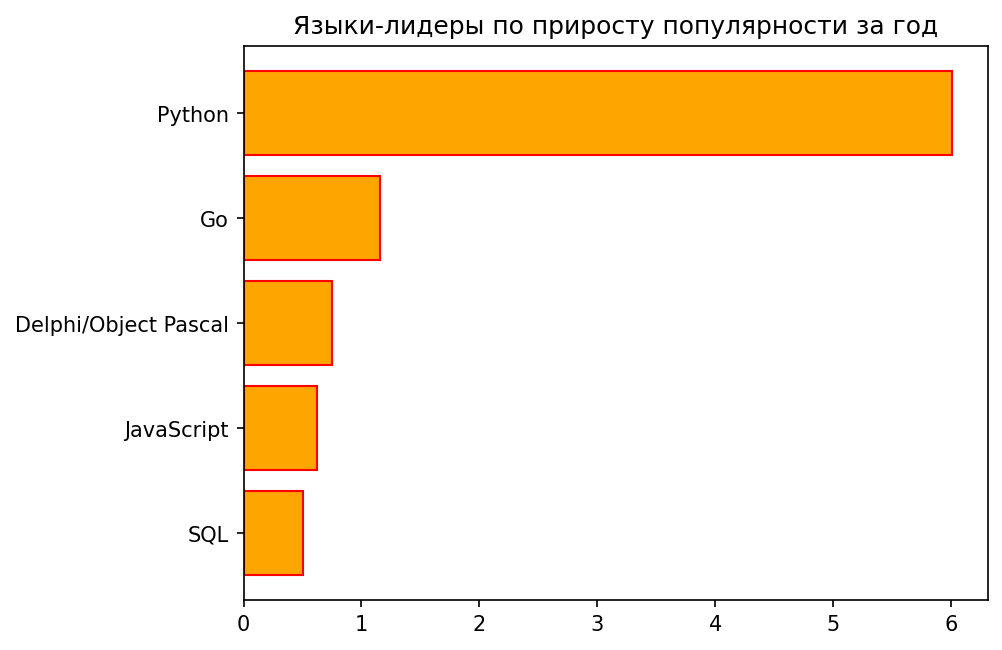

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

top_20 = tbpy.top_20()
top_20['Change.1'] = top_20['Change.1'].apply(lambda x: float(x.strip("%")))
top_20.sort_values('Change.1', ascending=False, inplace=True)
fig, ax = plt.subplots(1, 1)
fig.dpi = 150
plt.title('Языки-лидеры по приросту популярности за год')
plt.barh(top_20['Programming Language.1'][4::-1],
        top_20['Change.1'][4::-1],
        color='orange', edgecolor='red')
plt.show()

Источник: https://www.kaggle.com/nulldata/visualize-programming-language-popularity-python/

## Алгоритм
В основе программирования лежит понятие алгоритма. Если кратко, то алгоритм — это вычислимая функция. Если вам непонятно, давайте обратимся к школьному определению:

**Алгоритм** — это:
1. последовательность команд
2. на формальном языке исполнителя,
3. приводящая к цели
4. за конечное время.

Как видите, в самом определении заложена **формальность** языка описания алгоритма, а значит, его нельзя описать обычными словами.
**Исполнитель** команд будет выполнять их формально, "без души", "для галочки". То есть он не будет их "додумывать", пытаться догадаться о необходимом действии по обстоятельствам, если, конечно, выбор действия не прописан в самом алгоритме. Чёткость и однозначность работы исполнителя также выражают понятием **детерминированность алгоритма**. В поведении исполнителя нет места случайности. Если она нужна, её функцию выполняют псевдослучайные числа или же случайность "добывают" из окружающей реальности.
**Конечность** времени выполнения также важна: исполнитель не должен вечно приближаться к цели, зациклившись на каких-то действиях. Он должен достичь цели и остановить свою работу.

## Основы программирования с исполнителем turtle
Исполнитель Черепашка придуман Wally Feurzeig, Seymour Papert и Cynthia Solomon ещё в 1967 году для учебного языка программирования Logo. Теперь этот исполнитель есть в подавляющем большинстве языков программирования, которые претендуют на то, чтобы быть первым языком при обучении программированию.

Благодаря управлению Черепашкой можно *прочувствовать понятие алгоритма*, получить опыт его выражения формальным языком.

### Особенности подключения модуля
В интерактивном режиме при запуске программы на компьютере пользователя должен быть использован оригинальный модуль `turtle`. Он подключается так:
``` python
from turtle import *
```

Однако в данной лекции мы будем пользоваться ColabTurtle, который работает прямо в Jupyter Notebook и в Google Colab. Он подключается так:
```python
from ColabTurtle.Turtle import *
initializeTurtle()
```

Для того, чтобы он заработал, нужно один раз установить этот модуль вот такой командой (вам следует выполнить следующую ячейку, если вы захотите изменять программы для Черепашки и запускать модифицированные версии):

In [ ]:
!pip install ColabTurtle

  Preparing metadata (setup.py) ... done
  Created wheel for ColabTurtle: filename=ColabTurtle-2.1.0-py3-none-any.whl size=7642 sha256=f4fba818757bf4b0a31640d18e522cb930c03291a783f39a95efab10dd0e9ad6
  Stored in directory: /root/.cache/pip/wheels/5b/86/e8/54f5c8c853606e3a3060bb2e60363cbed632374a12e0f33ffc
Successfully built ColabTurtle


### Последовательное исполнение
Черепашка находится на плоскости на гладком песке и рисует узоры своим хвостом.

**Команды "черепашки"**


`forward(n)` - продвижение черепашки вперед на `n` шагов.

`backward(n)` - продвижение черепашки назад на `n` шагов.

`right(a)` - поворот на `a` градусов вправо.

`left(a)` - поворот на `a` градусов влево.

`penup()` - поднять "перо"-хвост (после этого движения черепашки не будут оставлять след на экране).

`pendown()` - опустить "перо"-хвост (после этого все движения черепашки будут оставлять след на экране).

`speed(m)` - задать скорость `m` (`m` может принимать значения от 1 до 13, 1 - самая медленная скорость, 13 - самая быстрая.

`shape("turtle")` - задать форму "черепашка".

`goto(x, y)` - перейти в точку с координатами `x` и `y`.

Давайте попробуем записать и выполнить последовательность действий:

In [ ]:
from ColabTurtle.Turtle import *

In [ ]:
initializeTurtle()
speed(1)
penup()
goto(200, 250)
pendown()
pensize(3)

forward(100)
right(150)
forward(60)
left(120)
forward(60)
left(30)
backward(100)
right(90)
penup()
forward(20)
pendown()
left(90)
forward(100)
right(90)
forward(60)
penup()
right(90)
forward(100)
left(90)
forward(20)
pendown()
left(60)
forward(116)
backward(58)
left(60)
forward(58)
penup()
backward(116)
right(120)

## Циклы и вложенные циклы
Одна из замечательных возможностей программирования — **циклы**, которые дают возможность **зацикливать выполнение команд**.

Для этого используются две **синтаксические конструкции языка**: цикл `while` и цикл `for`.
Вместо циклов для повторения действий также может использоваться специальный приём под названием *рекурсия*, но в данном курсе мы не будем его использовать.

Цикл `for` состоит из *заголовка* и *тела цикла*:

```python
for счётчик in значения, которые нужно перебрать:
    команды
    тела
    цикла
    сдвинуты
    вправо
команда_вне_цикла
```

Команды тела цикла выполняются столько раз, сколько значений требуется перебрать в списке из заголовка.
При этом текущее значение доступно в счётчике цикла.

Команды тела цикла должны быть сдвинуты вправо на 4 пробела. А первая же команда без отступа — это уже команда за пределами цикла, а значит, её выполнение не будет повторяться.

Циклы удобны для рисования многоугольников. Нарисуем **пятиугольник**:

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
speed(5)
penup()
goto(200, 250)
pendown()
for step in 1, 2, 3, 4, 5:
    forward(120)
    right(360 / 5)
    print(step)
print("Это пятиугольник.")

1
2
3
4
5
Это пятиугольник.


Обратите внимание, что команды движения вперёд и поворота направо написаны один раз, а выполнились пять раз.
Однократное выполнение команд тела цикла называется **итерацией**.

Допустимо говорить так: "*в цикле пять итераций*", "*на первой итерации рисуется первое ребро*", "*на последней итерации ломаная замыкается в пятиугольник*".

Также мы увидели результат команды `print`. Если быть точным, это не команда, а вызов функции печати текста. `print` находится после тела цикла и написана без сдвига, поэтому выполнилась *только один раз*, когда выполнение цикла было завершено.

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
speed(5)
penup()
goto(400, 250)
pendown()
for side in 1, 2, 3:
    forward(120)
    left(120)
    print("Это треугольник.")

Это треугольник.
Это треугольник.
Это треугольник.


В программе выше мы подвинули команду `print` вправо, и теперь она *стала частью тела цикла*. Поэтому мы и видим надпись "Это треугольник." три раза.

Можно было бы также печатать значение счётчика `print(side)`.

Теперь давайте посмотрим, что будет, если поместить цикл из второй программы в первую. Это называется **вложенные циклы**:

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
speed(5)
penup()
goto(200, 250)
pendown()
for step in 1, 2, 3, 4, 5:
    forward(120)
    right(360 / 5)
    for side in 1, 2, 3:
        forward(120)
        left(120)
print("Звездочка!")

Звездочка!


Давайте вернёмся к рисованию простых многоугольников.

Обратите внимание, что форма фигуры зависит не только и не столько от количества итераций, сколько от угла поворота.

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
penup()
goto(200, 250)
pendown()
speed(5)
for step in 1, 2, 3, 4, 5, 6, 7, 8, 9, 10:
    forward(120)
    right(60)

Угол 60 градусов является "внешним" углом шестиугольника, поэтому получается шестиугольник, хотя итераций 10 штук.

А что, если угол поворота будет больше 90 градусов? Например, за 5 поворотов повернёмся на 720 градусов (два полных оборота):

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
penup()
goto(200, 250)
pendown()
speed(7)
for step in 1, 2, 3, 4, 5:
    forward(120)
    right(2*360 / 5)

Попробуйте рассчитать, какой угол потребуется для рисования правильного 8-угольника и правильного 10-угольника.

### Простые функции-«процедуры» без параметров
Для того, чтобы легко было повторить выполнение некоторых действий, нужно *выделить их в отдельный алгоритм*.

В Python такие алгоритмы называются **функции**, но смысл их не в том, чтобы что-то вычислить, а в том, чтобы осуществить действия, некоторую **процедуру**.

Синтаксис описания простой функции такой:
```python
def some_name_of_function():
    action1
    action2
    ...
```

Строка с `def` называется **заголовком функции**, а сдвинутый на 4 пробела текст является **телом функции**.

Именно эти команды будут запускаться, когда будет осуществлён **вызов функции**.

Для того, чтобы вызвать функцию, нужно написать её имя вместе с круглыми скобками. Если функцию не вызвать, а только описать, ничего не произойдёт.

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
penup()
goto(200, 250)
pendown()
speed(10)
def small_star():
    for step in 1, 2, 3, 4, 5:
        forward(50)
        right(360 / 5)
        for side in 1, 2, 3:
            forward(50)
            left(120)

small_star()

Одно из преимуществ функции в том, что, однажды описав, её можно вызывать многократно.

Используем нашу функцию, чтобы нарисовать несколько звёзд:

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
penup()
goto(50, 150)
pendown()
speed(10)
right(90)
def small_star():
    for step in 1, 2, 3, 4, 5:
        forward(30)
        right(360 / 5)
        for side in 1, 2, 3:
            forward(30)
            left(120)

for star in 1, 2, 3:
    small_star()
    forward(120)

forward(100)
right(90)
forward(100)

Печальная картина... Видно, что остаётся "грязь", т.к. мы не подняли перо при сдвиге от звезды к звезде.

Лучше всего это исправить, если *договориться*, в каком состоянии должно быть перо в момент вызова функции и в каком состоянии оно должно остаться после него.

Давайте опускать перо в начале работы функции и поднимать по окончании её работы.

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
penup()
goto(50, 150)
speed(10)
right(90)
def small_star():
    pendown()  # соблюдение договорённости
    for step in 1, 2, 3, 4, 5:
        forward(30)
        right(360 / 5)
        for side in 1, 2, 3:
            forward(30)
            left(120)
    penup()  # соблюдение договорённости

for star in 1, 2, 3:
    small_star()
    forward(120)

forward(100)
right(90)
forward(100)

Такую договорённость называют **контрактом функции**.

Это в каком-то смысле *юридическая составляющая* программирования. Если мы пишем детский учебный программный код, то в нём мы можем не создавать и не соблюдать никаких контрактов (как их нет в общении детей в детском садике), но в серьёзных программных комплексах очень важна **отказоустойчивость программы**. Поэтому функции считаются написанными качественно, если они не только быстро и точно выполняют свою задачу, но и проверяют условия контракта как на входе, так и на выходе из потока выполнения кода функции.

В рамках курса этот подход изучаться не будет. Желающие могут подробнее узнать про **контрактное программирование** в книгах [Бертрана Мейера](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D0%B9%D0%B5%D1%80,_%D0%91%D0%B5%D1%80%D1%82%D1%80%D0%B0%D0%BD).

### Функции с параметрами
Для того, чтобы функция могла работать немного по-разному от вызова к вызову, её можно *параметризовать* — добавить **параметры функции**.

Синтаксически они пишутся после её имени в круглых скобках. Если параметров несколько, они указываются через запятую.
До момента вызова они не наполнены никакими значениями, поэтому имена параметров, их **идентификаторы**, называются **формальными параметрами**.

При вызове функции мы передаём **фактические значения параметров** — конкретные числа, которые "наполнят" содержанием формальные параметры.


In [ ]:
def foo(x):
    print('Значение параметра x =', x)

foo(5)
foo(10)

Значение параметра x = 5
Значение параметра x = 10


In [ ]:
def registration(name, course):
    print('Уважаемый(ая),', name)
    print("Вы записаны на курс:", course)

In [ ]:
registration('Тимофей', 'Основы анализа данных на Python')

Уважаемый(ая), Тимофей
Вы записаны на курс: Основы анализа данных на Python


In [ ]:
registration('Ольга', 'Решение прикладных задач на Python')

Уважаемый(ая), Ольга
Вы записаны на курс: Решение прикладных задач на Python


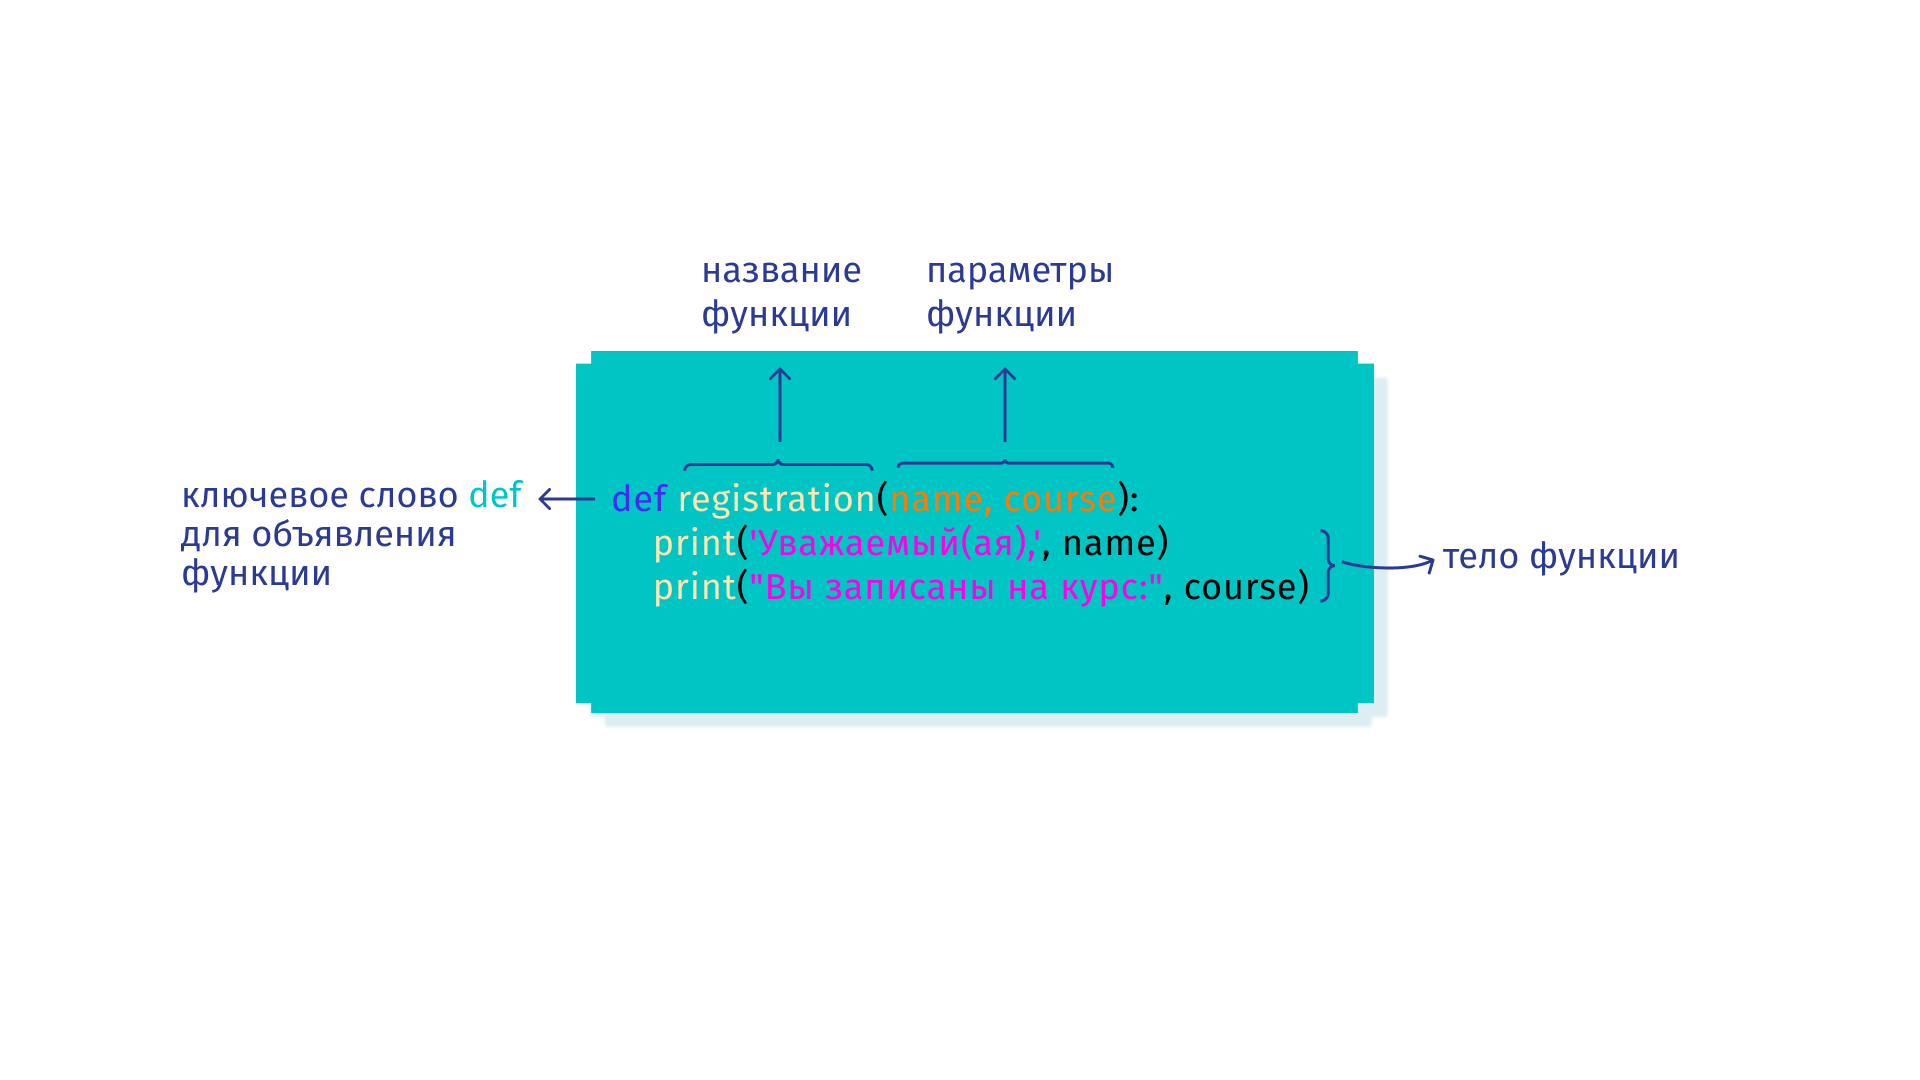

Воспользуемся новым знанием!
Добавим в функцию рисования звезды параметр — размер ребра:

In [ ]:
from ColabTurtle.Turtle import *
initializeTurtle()
penup()
goto(60, 150)
speed(10)
def small_star(length):
    pendown()
    for step in 1, 2, 3, 4, 5:
        forward(length)
        right(360 / 5)
        for side in 1, 2, 3:
            forward(length)
            left(120)
    penup()

right(90)
for star in 1, 2, 3:
    small_star(star*30)
    forward(star*90 + 40)

## Вызов функций из функций
Из тела функции тоже можно вызывать функции. При этом вызывавшая сторона ожидает "в заморозке" до тех пор, пока вызванная не закончит свою работу.

Такой ход исполнения называется **синхронным вызовом** и подразумевает, что исполнитель (в нашем случае это интерпретатор Python) однозадачный и может исполнять одновременно только одно действие.

Посмотрим на работу синхронных вызовов вот этих функций:

In [ ]:
def grandfather():
    print('Дедка зовёт бабку.')
    grandmother()
    print('Дедка за репку!')

def grandmother():
    print('Бабка зовёт внучку.')
    granddaughter()
    print('Бабка за дедку.')

def granddaughter():
    print('Внучка зовёт жучку.')
    dog()
    print('Внучка за бабку!')

def dog():
    print('Жучка зовёт кошку.')
    cat()
    print('Жучка за внучку!')

def cat():
    print('Кошка зовёт мышку.')
    mouse()
    print('Кошка за жучку!')

def mouse():
    print('Мышка никого не зовёт. Мышка просто тянет за кошку.')

Итак, все функции описаны, но не запущены.
Теперь вызовем функцию `grandfather` и посмотрим за ходом выполнения команд:

In [ ]:
grandfather()
print("Ура! И вытянули репку!")

Дедка зовёт бабку.
Бабка зовёт внучку.
Внучка зовёт жучку.
Жучка зовёт кошку.
Кошка зовёт мышку.
Мышка никого не зовёт. Мышка просто тянет за кошку.
Кошка за жучку!
Жучка за внучку!
Внучка за бабку!
Бабка за дедку.
Дедка за репку!
Ура! И вытянули репку!


Обратите внимание, что ход исполнения вначале "спускается вглубь" вызовов, а потом "выныривает на поверхность".

Так происходит и у людей, когда им приходится делегировать другим людям выполнение задачи, без которой невозможно дальнейшее действие. Так и дедка не может продуктивно тянуть репку, пока бабка не потянет его.

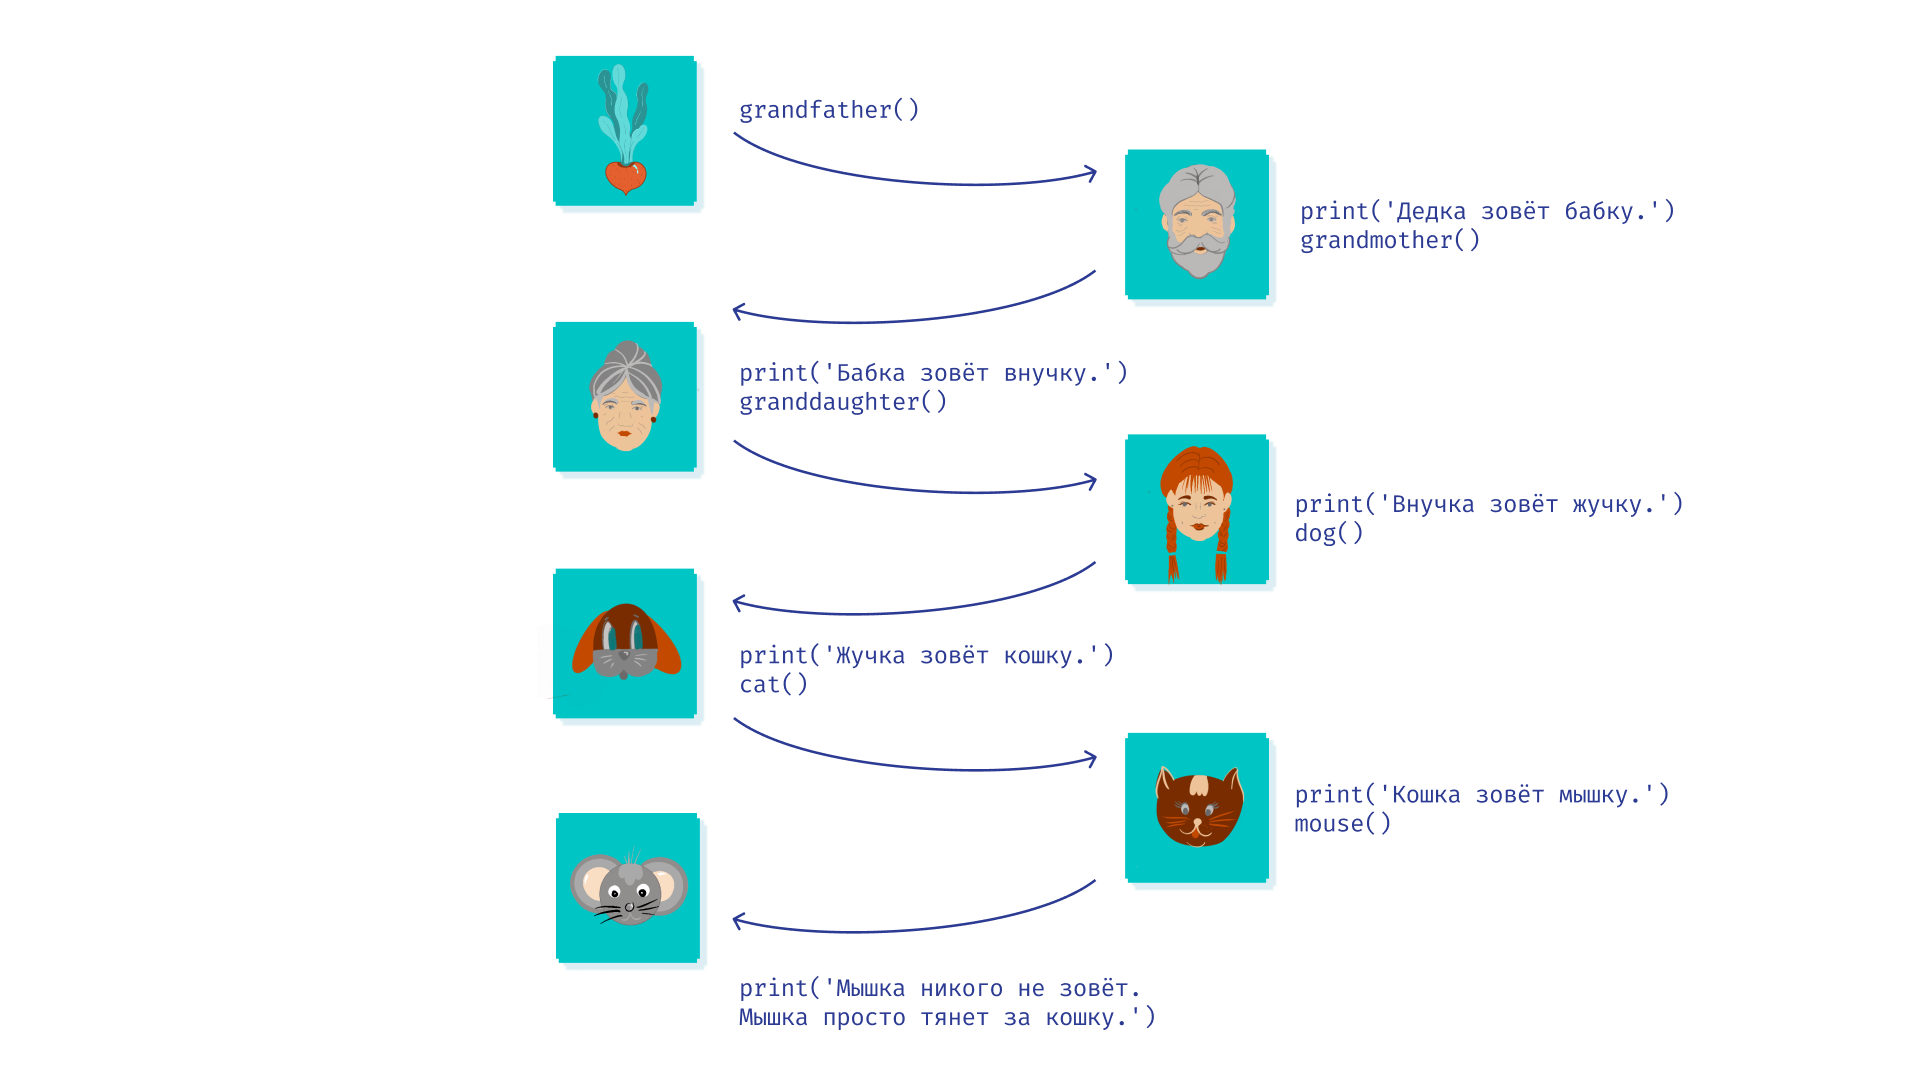

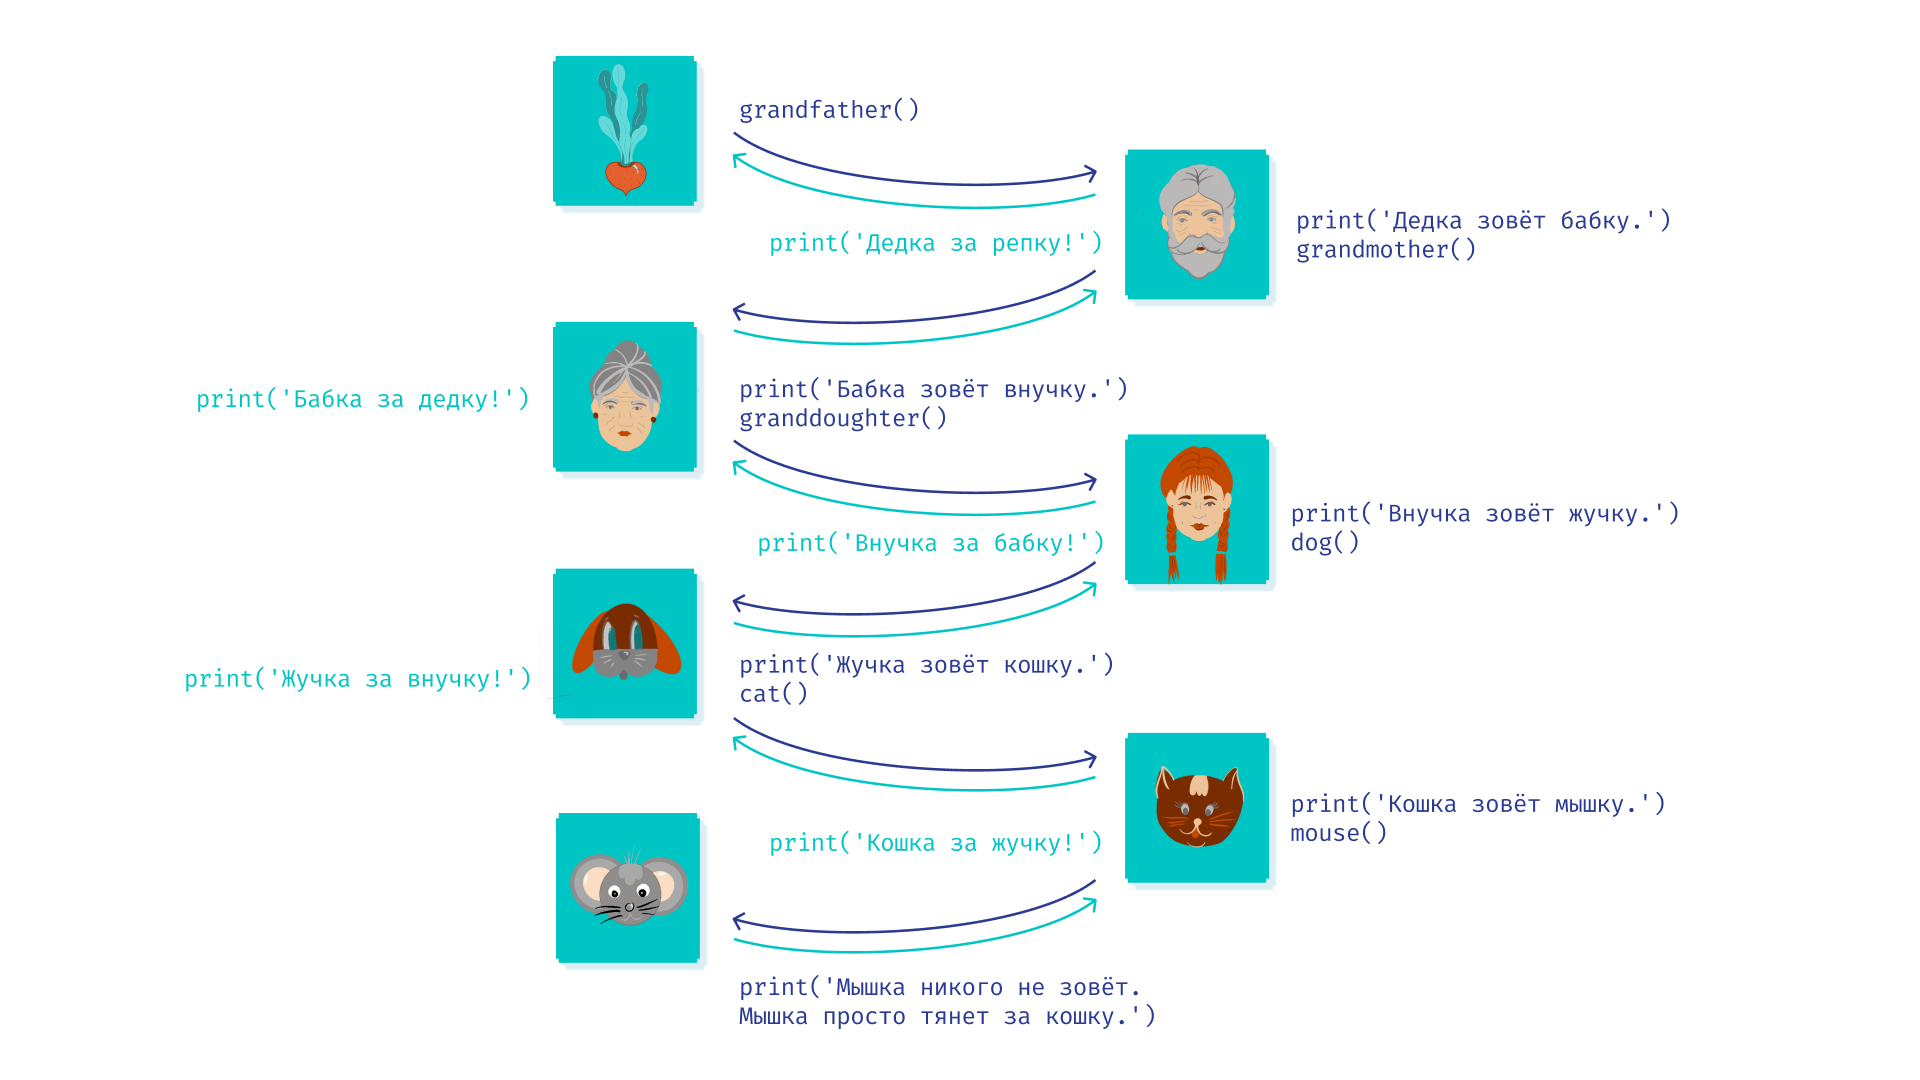

## Ввод и вывод информации функциями `input` и `print`

Как вы уже видели, функция `print` выводит текстовую информацию на экран. При этом можно выводить значение не одного, а нескольких выражений, для этого нужно перечислить их через запятую:

In [ ]:
hours = 16
minutes = 28
seconds = 10
print(hours, minutes, seconds)

16 28 10


Обратите внимание, выводимые значения разделяются одним пробелом. Но такое поведение можно изменить: можно разделять выводимые значения двумя пробелами, любым другим символом, любой другой строкой, выводить их в отдельных строках или не разделять никак.

Для этого у функции `print` есть "именованный параметр" `sep`. По умолчанию параметр `sep` равен строке из одного пробела и поэтому между значениями выводится пробел. Чтобы использовать в качестве разделителя, например, символ двоеточия нужно передать ему значение `':'`:

In [ ]:
print(hours, minutes, seconds, sep=':')

16:28:10


В свою очередь функция `input()` предназначена для запроса текстовой информации от пользователя. Она считывает одну строку с клавиатуры, например:

In [2]:
name = input("Введите своё имя:")

Введите своё имя: ss


In [3]:
print("Здравствуйте, ", name, "!", sep="")

Здравствуйте, ss!


In [ ]:
print("Введите возраст:")
age = int(input())

Введите возраст:
19


In [ ]:
age = age + 1
print("А скоро тебе будет", age, "лет!")

А скоро тебе будет 20 лет!


Обратите внимание, что для работы с введёнными символами как с числом нам потребовалось явно преобразовать возраст к числу: `int(input())`.

## Операции сравнения

Для анализа значений чисел нам нужны **операции сравнения**: `==`, `!=`, `>`, `<`, `<=`, `>=`.

In [ ]:
2 + 2 == 4

True

In [ ]:
2 + 2 != 4

False

In [ ]:
3 > 3

False

In [ ]:
3 >= 3

True

Операции сравнения возвращают специальные значения `True` и `False`, которые называются **логическими**.

Они нужны для принятия решений программой.

# Ветвление хода исполнения программы
До сих пор наши программы представляли из себя *последовательности действий*, возможно с зацикливаниями.
В таких алгоритмах нет вариативности поведения, не хватает возможности выбора действий, то есть **ветвления**.

Самый простой вариант ветвления — это *действие, выполняемое условно*. Оно может произойти, а может и нет.

Синтаксис **условного выполнения** таков: пишется оператор `if`, затем логическое условие, двоеточие, а затем сама команда или несколько команд.

Все условно исполняемые команды должны быть сдвинуты на 4 пробела от уровня оператора `if`.
```python
if условие + выполнения > 0:
    тут_условно_выполняющаяся_команда
команда_вот_тут_выполняется = по-любому
```

Обратите внимание, что первая же команда, которая не сдвинута на 4 пробела, выполняется всегда, без всяких условий.

In [ ]:
x = int(input("Сколько вам лет? "))
if x < 0:
    print('Такого не может быть! Вы не можете родиться в будущем.')

Сколько вам лет? -2
Такого не может быть! Вы не можете родиться в будущем.


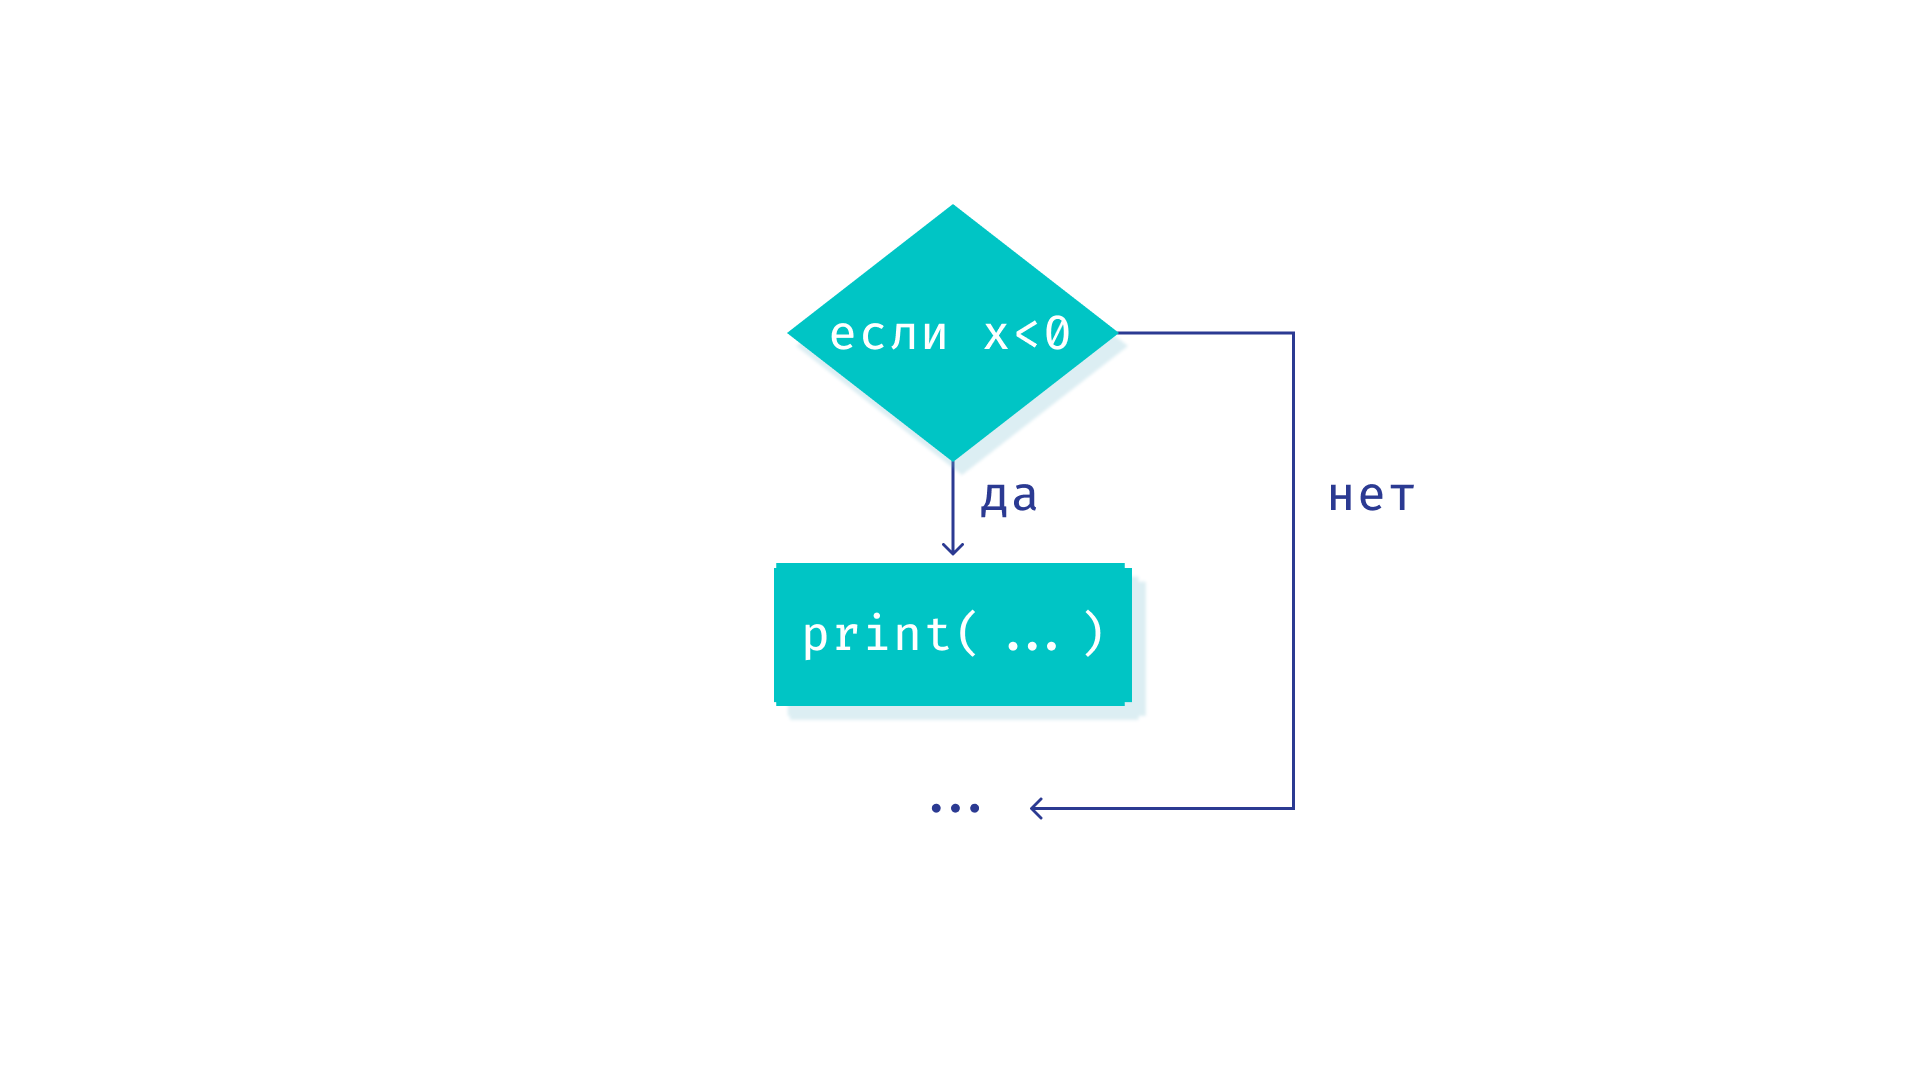

Второй вариант — это *ветвление с альтернативой*:

In [ ]:
x = int(input("Сколько вам лет? "))
if x < 18:
    print(f'Вам нельзя смотреть этот фильм! Приходите через {18-x} лет.')
else:
    print('Фильм загружается. Ждите...')
print("Обязательно случится.")

Сколько вам лет? 12
Вам нельзя смотреть этот фильм! Приходите через 6 лет.
Обязательно случится.


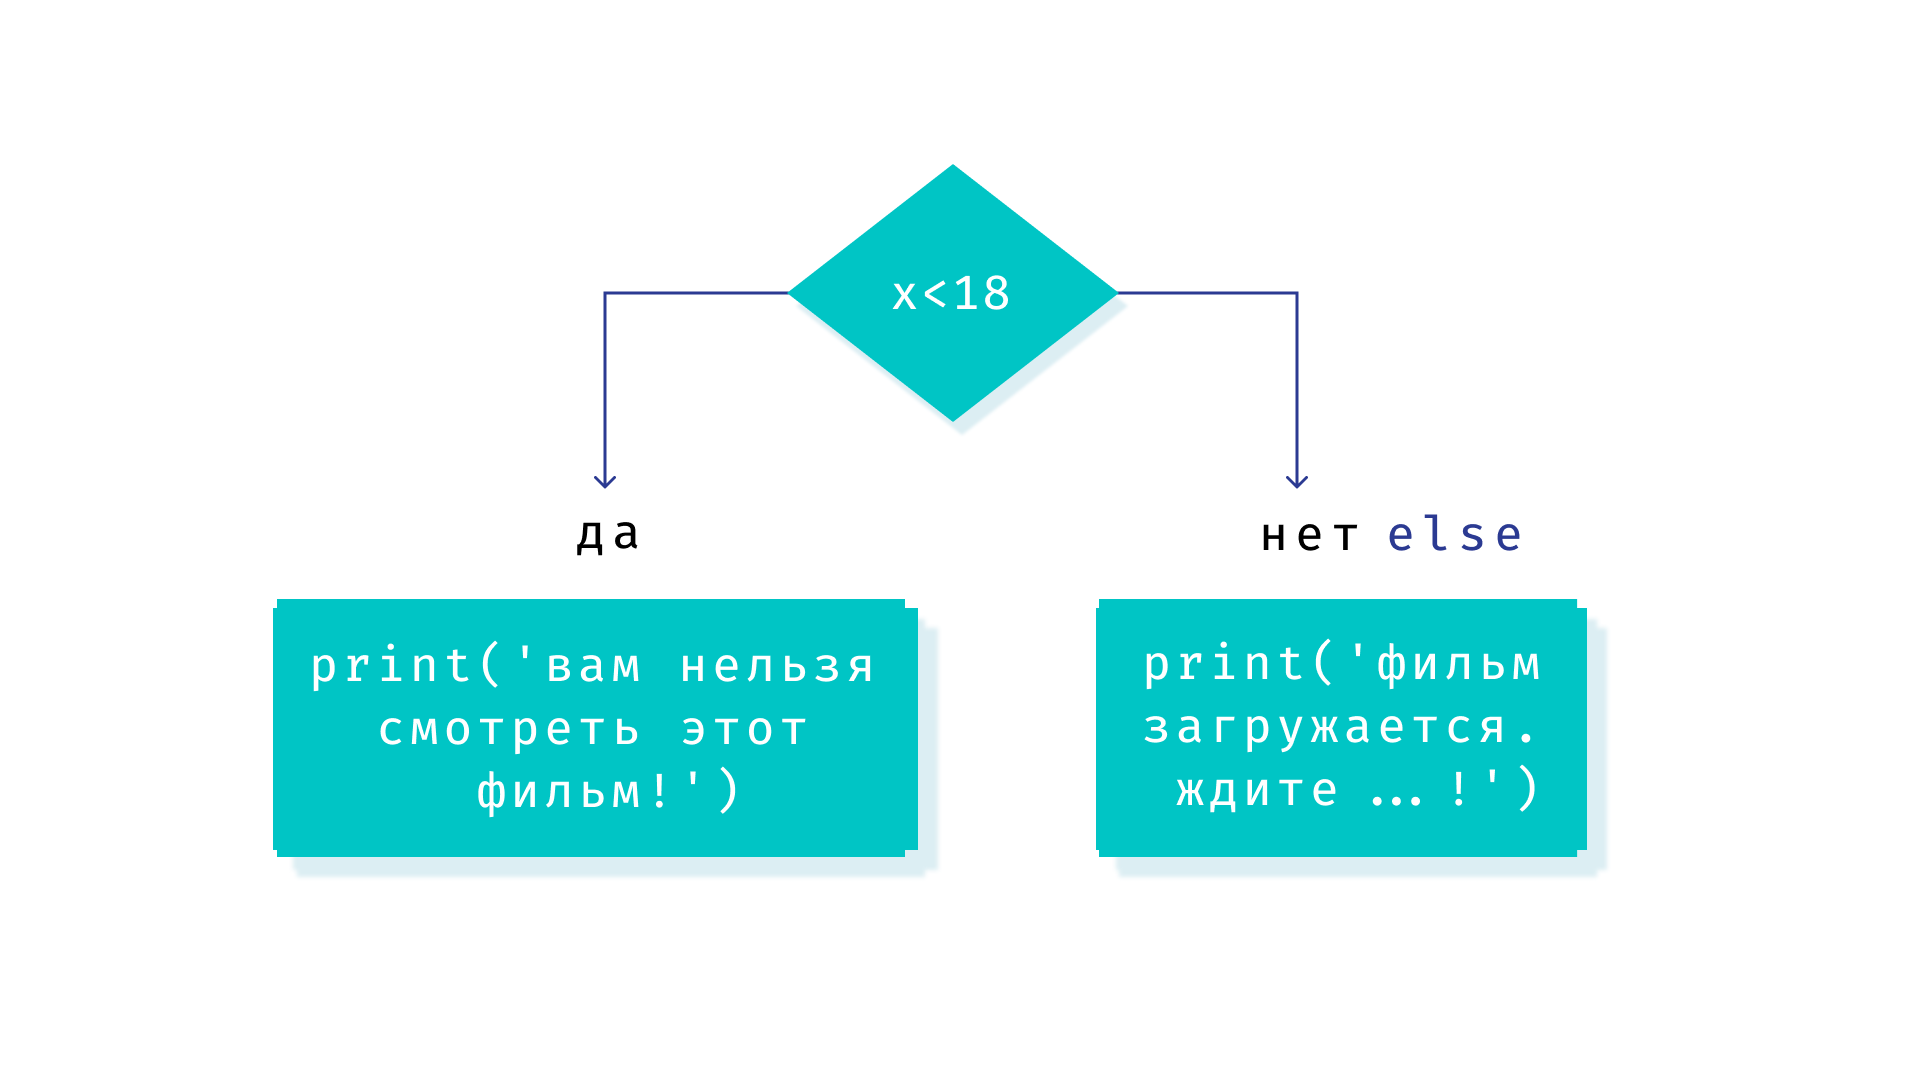

## Вложенные условные конструкции
Как и циклы, условные конструкции можно вкладывать друг в друга. Для этого дополнительно увеличивается отступ:

In [ ]:
print("Введите координаты точки на картезианской плоскости",
      "— 2 числа через пробел:")
x, y = input().split()
x, y = int(x), int(y)
if y > 0:
    if x > 0:
        print('Точка в I четверти.')
    else:
        print('Точка во II четверти.')
else:
    if x < 0:
        print('Точка в III четверти.')
    else:
        print('Точка в IV четверти.')

Введите координаты точки на картезианской плоскости — 2 числа через пробел:
1 5
Точка в I четверти.


Замечательно! Из четырёх `print` будет всегда выбираться и срабатывать только один.

Но кое-что всё-таки не так с этой конструкцией. Мы предполагаем, что точка вообще находится в какой-то четверти, а она может быть и на осях. Поэкспериментируйте с точками (0, 0), (0, 10), (0, -10), (1, 0), (-1, 0). Сделайте вывод о том, нужно ли тестировать программное обеспечение.

## Каскадная конструкция if, elif, else
Реализуем то же самое действие при помощи каскадного ветвления:

In [ ]:
x, y = input("Введите координаты точки на картезианской плоскости — два числа через пробел: ").split()
x, y = int(x), int(y)
if y > 0 and x > 0:
    print('Точка в I четверти.')
else:
    if y > 0 and x < 0:
        print('Точка во II четверти.')
    else:
        if y < 0 and x < 0:
            print('Точка в III четверти.')
        else:
            if y < 0 and x > 0:
                print('Точка в IV четверти.')
            else:
                print('Точка не в четвертях: на осях или в центре координат.')

Введите координаты точки на картезианской плоскости — два числа через пробел: 0 -5
Точка не в четвертях: на осях или в центре координат.


**NB!** Обратите внимание на логический оператор И = `and`. Ещё есть логическое ИЛИ = `or` и логическое НЕ = `not`. Их используют для составных условий в циклах while и ветвлениях.

Продолжим. Конструкция напоминает водопад, по которому мы скатываемся до тех пор, пока хотя бы какое-то условие не окажется истинным. Если же всё было ложно, мы "скатываемся" по последней альтернативе — последнему else.

Всё здесь хорошо, но отступы всё время увеличиваются. Чтобы избежать этого, в Python ввели *синтаксический сахар* — `elif`:

In [ ]:
x, y = input("Введите координаты точки на картезианской плоскости — два числа через пробел: ").split()
x, y = int(x), int(y)
if y > 0 and x > 0:
    print('Точка в I четверти.')
elif y > 0 and x < 0:
    print('Точка во II четверти.')
elif y < 0 and x < 0:
    print('Точка в III четверти.')
elif y < 0 and x > 0:
    print('Точка в IV четверти.')
else:
    print('Точка не в четвертях: на осях или в центре координат.')

Введите координаты точки на картезианской плоскости — два числа через пробел: 0 -5
Точка не в четвертях: на осях или в центре координат.


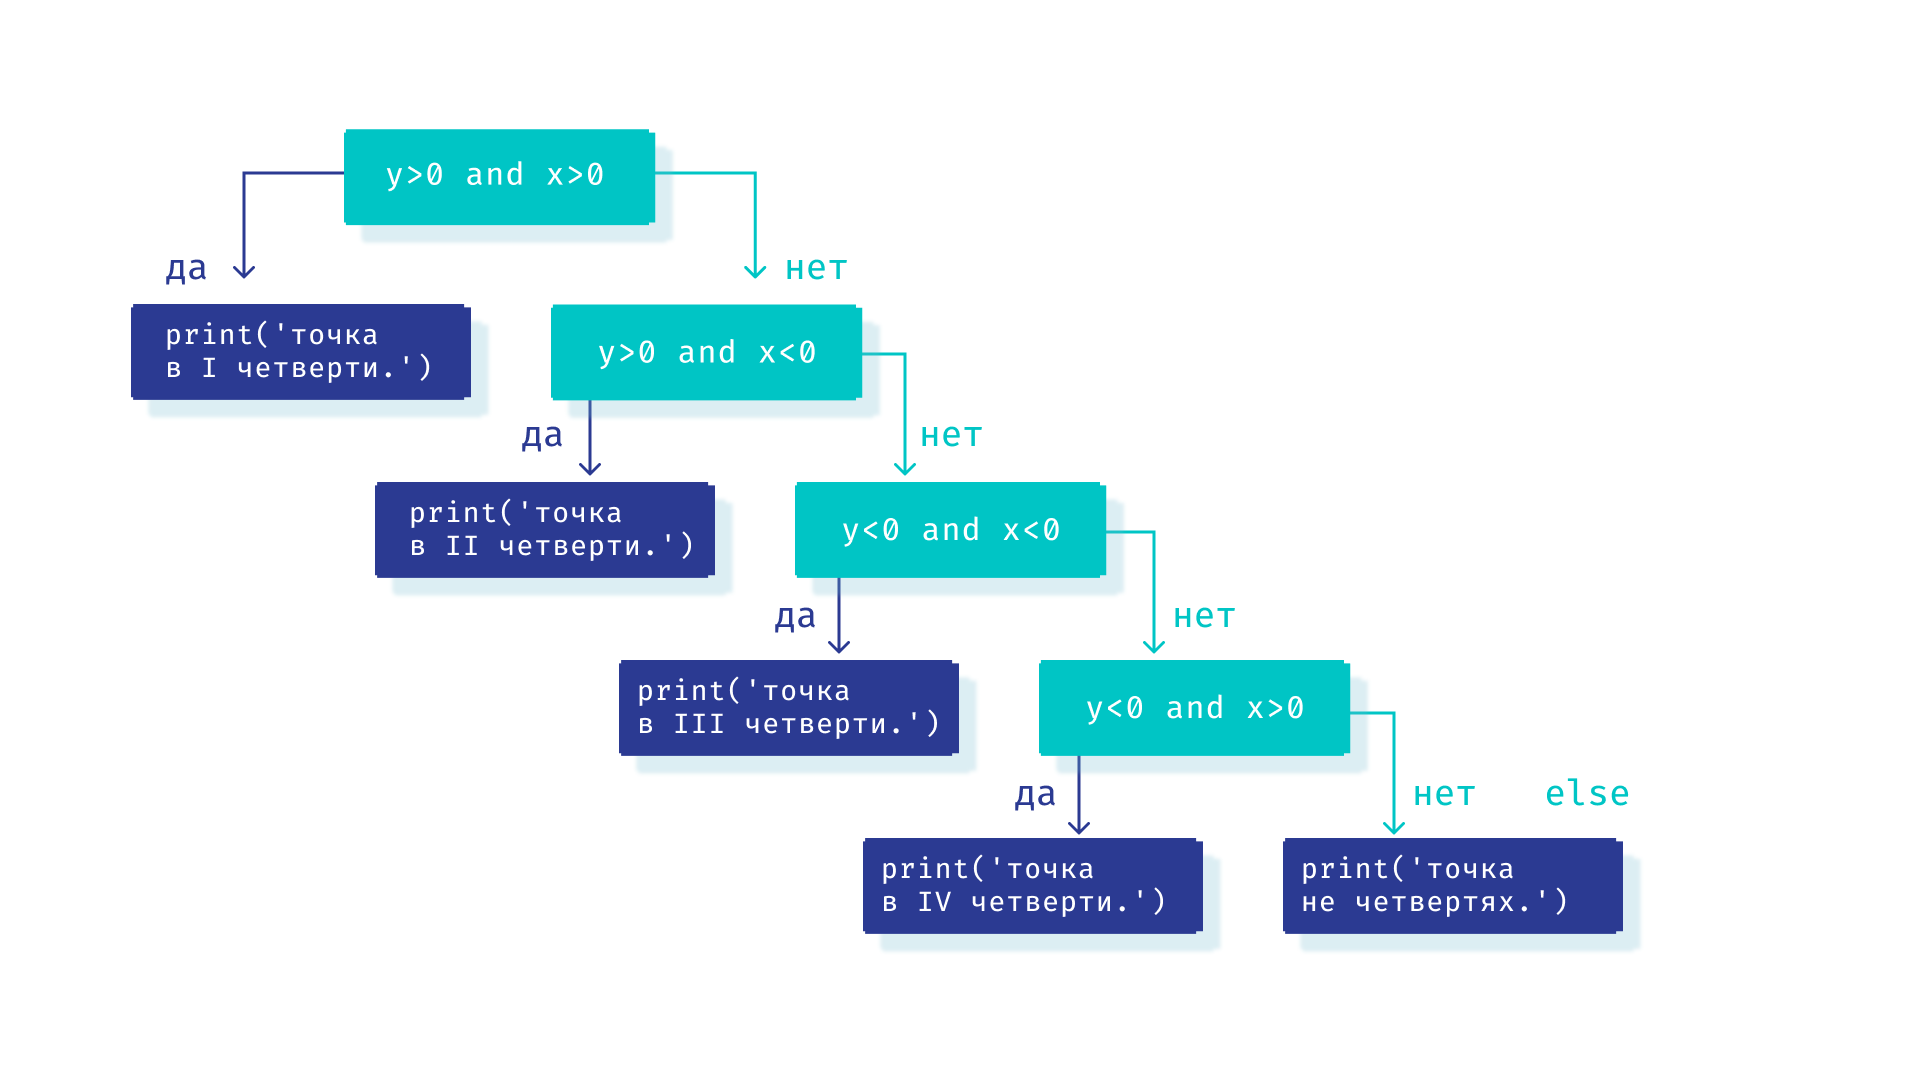

## Цикл `for` и функция `range` в задачах ввода-вывода

Выше мы уже зацикливали действия исполнителя при помощи цикла `for`, но значения переменной-счётчика мы задавали прямым их перечислением. Это не позволяет сделать переменное количество итераций.

Для отсчёта `n` итераций можно использовать функцию `range(n)`:

In [ ]:
n = int(input("Сколько итераций сделать: "))
for x in range(n):
    print(x)

Сколько итераций сделать: 5
0
1
2
3
4


Заметим, что отсчёт значений начинается с 0 и не достигает 5.

Можно сделать вложенные циклы `for` с двумя разными переменными-счётчиками, и добиться разного количества итераций вложенного цикла в зависимости от номера итерации внешнего цикла.

In [ ]:
n = int(input())
for x in range(n):
    for y in range(x + 1):
        print("*", end=" ")
    print()  # Перевод строки в конце внешнего цикла

6
* 
* * 
* * * 
* * * * 
* * * * * 
* * * * * * 


### Считывание и обработка потока чисел
Если нужно прочитать N чисел с клавиатуры, то само считывание должно находиться в теле цикла.

#### Решим задачу "Паровозики из чисел"
В первой строке ввода дано количество чисел $N$. Затем следует $N$ строк с числами.
Для каждого такого числа $x_i$ вывести все числа от $0$ до $x_i$ включительно, разделяя их знаком $\#$.

In [ ]:
2N = int(input())
for i in range(N):  # будем считывать число x N раз
    x = int(input())
    for y in range(x):  # перебираем все числа от 0 до предпоследнего x-1, не включая x
        print(y, end='#')  # ставим очередной "вагончик" и сцепку
    print(x)  # допечатываем после цикла само число x и ставим перенос строки после "паровозика"

6
10
0#1#2#3#4#5#6#7#8#9#10
5
0#1#2#3#4#5
20
0#1#2#3#4#5#6#7#8#9#10#11#12#13#14#15#16#17#18#19#20
2
0#1#2
1
0#1
8
0#1#2#3#4#5#6#7#8


## Заключение
Программирование в 21-м веке необходимо всем факультетам МГУ! Более того, оно требует особенных навыков, которые есть не только у технарей. А именно, в программировании есть:

1. Гуманитарная составляющая — названия объектов.
2. Управленческая составляющая — проектирование функций и их интерфейсов взаимодействия.
3. Юридическая составляющая — контракты функций.
4. Эстетическая составляющая — качество программного кода.
5. Математическая составляющая — разработка эффективных алгоритмов.
6. Физическая составляющая  — моделирование движения.

## *Бонус к лекции. Пример моделирования материальной точки

In [5]:
from turtle import *

speed(8)
x = 0
y = 280
vx = 8
vy = -20
ay = 1
penup()
goto(x, y)
pendown()
for t in range(80):
    goto(x, y)
    x = x + vx
    y = y + vy + ay
    vy = vy + ay
    if y >= 280:
        vy = -vy*0.6
print("Моделирование завершено.")

Моделирование завершено.
